# Health Care Insurance Premium Prediction — Part 2: Regression & Classification Models

This notebook loads `cleaned_data.csv` produced in Part 1 and builds two predictive models: a **regression** model that predicts the continuous `expenses` value, and a **binary classification** model that predicts whether a policyholder is a high-cost case (above the median) or not. All preprocessing is done leak-free (scaler fit only on training data), and both models are evaluated rigorously.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, confusion_matrix,
                              classification_report, roc_curve, roc_auc_score,
                              precision_score, recall_score, f1_score)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

## Task 1 — Load data and define features / labels

- **Feature matrix `X`**: every column except `expenses`.
- **Regression label `y_reg`**: `expenses` (continuous — the medical cost billed).
- **Classification label `y_clf`**: a binary "high-cost policyholder" flag, derived by binarizing
  `expenses` at its own median: `1` if `expenses` is above the sample median, `0` otherwise. This is a
  natural business-relevant label (identify above-median-risk policyholders) rather than an arbitrary cut.

In [2]:
df = pd.read_csv('cleaned_data.csv')
print("Shape:", df.shape)

y_reg = df['expenses']
y_clf = (y_reg > y_reg.median()).astype(int)
X = df.drop(columns=['expenses'])

print("y_reg (regression target) — first 5:")
print(y_reg.head())
print("\ny_clf (classification target) value counts:")
print(y_clf.value_counts())
print(f"\nMedian expenses used as the classification cutoff: {y_reg.median():.2f}")

Shape: (500, 7)
y_reg (regression target) — first 5:
0     9095.07
1     5272.18
2    29330.98
3     9301.89
4    33750.29
Name: expenses, dtype: float64

y_clf (classification target) value counts:
expenses
0    250
1    250
Name: count, dtype: int64

Median expenses used as the classification cutoff: 9238.70


## Task 2 — Encode categorical columns

`sex`, `smoker`, and `region` are all categorical. **None of them have a natural order** — there's no
sense in which `male < female`, `no < yes` for smoking, or `northeast < southeast` for region. Label
encoding any of these would introduce a **false ordinal relationship** (e.g. it would tell the model that
"southwest" is numerically greater than "northeast", which is meaningless and could bias coefficient
estimates). So all three are **one-hot encoded** instead, using `pd.get_dummies()` with
`drop_first=True` to avoid the dummy-variable trap (multicollinearity from redundant columns — with `k`
categories, only `k-1` dummy columns are needed since the last category is implied when all others are 0).

In [3]:
X_enc = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)
X_enc = X_enc.astype({c: 'int' for c in X_enc.select_dtypes('bool').columns})
print("Encoded feature columns:", X_enc.columns.tolist())
X_enc.head()

Encoded feature columns: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,45,25.2,2,0,0,0,0,0
1,36,30.0,0,0,0,1,0,0
2,64,26.9,0,0,1,1,0,0
3,46,25.7,3,1,0,1,0,0
4,19,31.9,0,1,1,1,0,0


## Task 3 — Leak-free train-test split and scaling

The split is done **before** any scaling. The `StandardScaler` is fit **only on `X_train`**, then used to
transform both `X_train` and `X_test`.

**Why fitting the scaler on the full dataset would be data leakage:** the scaler's mean and standard
deviation are statistics computed from data. If we fit it on the combined train+test set, the training
process would implicitly "see" information about the test set's distribution (its mean/variance) before
the model is ever evaluated — the test set is supposed to simulate genuinely unseen future data, and
future data's statistics cannot be known in advance. Fitting on the full dataset would make the
evaluation metrics optimistically biased and would not reflect real-world deployment, where the scaler
has to be fit once on historical data and then applied to new, never-before-seen records.

In [4]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_enc, y_reg, y_clf, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, " X_test:", X_test.shape)

scaler = StandardScaler()
scaler.fit(X_train)                      # fit ONLY on training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)  # test set transformed using training statistics

print("Scaling complete. Train mean (should be ~0):", X_train_scaled.mean(axis=0).round(3))

X_train: (400, 8)  X_test: (100, 8)
Scaling complete. Train mean (should be ~0): [ 0. -0.  0. -0.  0.  0.  0. -0.]


## Task 4 — Regression Model: Linear Regression

In [5]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)
y_pred_reg = lin_reg.predict(X_test_scaled)

mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)
print(f"Linear Regression — MSE: {mse:,.2f}")
print(f"Linear Regression — R²:  {r2:.4f}")

Linear Regression — MSE: 30,967,557.63
Linear Regression — R²:  0.7618


In [6]:
coef_series = pd.Series(lin_reg.coef_, index=X_train.columns).sort_values(key=lambda s: s.abs(), ascending=False)
print("Coefficients (sorted by |magnitude|):")
coef_series

Coefficients (sorted by |magnitude|):


smoker_yes          9837.679123
age                 3536.933577
bmi                 1962.299889
region_southeast    -620.438921
children             511.907620
sex_male            -468.103287
region_southwest    -315.124017
region_northwest      37.819155
dtype: float64

In [7]:
top3 = coef_series.index[:3].tolist()
print("Top 3 features by |coefficient|:", top3)

Top 3 features by |coefficient|: ['smoker_yes', 'age', 'bmi']


**Interpreting the coefficients** (features were scaled, so coefficients are directly comparable):

- A **large positive coefficient** means that a one-standard-deviation increase in that (scaled) feature
  is associated with an increase in predicted `expenses` of that many dollars, holding all other
  features constant. E.g. `smoker_yes` having the largest positive coefficient means going from
  non-smoker to smoker is associated with a large jump in predicted cost.
- A **large negative coefficient** means that feature is associated with a *decrease* in predicted
  `expenses` per standard deviation increase, holding everything else constant — e.g. a negative
  coefficient on a region dummy means that region tends to have lower costs than the reference region
  (the one dropped during one-hot encoding), all else equal.

## Task 4b — Ridge Regression Comparison

In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

comparison = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Ridge (alpha=1.0)'],
    'MSE': [mse, mse_ridge],
    'R2': [r2, r2_ridge]
})
comparison

,Model,MSE,R2
0,Linear Regression (OLS),3.096756e+07,0.761759
1,Ridge (alpha=1.0),3.094981e+07,0.761895


## Task 5 — Classification Model: Logistic Regression

**Class balance check:** since `y_clf` was constructed by splitting at the median of `expenses`, it is
close to perfectly balanced by design (250 / 250 overall). We still check the training split explicitly.

In [9]:
print("y_clf_train value counts (BEFORE any imbalance handling):")
print(y_clf_train.value_counts())
minority_pct = y_clf_train.value_counts(normalize=True).min()
print(f"\nMinority class share: {minority_pct:.1%}")

y_clf_train value counts (BEFORE any imbalance handling):
expenses
1    203
0    197
Name: count, dtype: int64

Minority class share: 49.2%


The minority class share is **~49.3%** — well above the 35% imbalance threshold from the brief. So,
strictly speaking, **no imbalance correction is required** here (the median-split construction guarantees
near-50/50 balance). To still follow best practice and make the model robust to any imbalance that could
appear in a future non-median-based label, the baseline model below uses `class_weight='balanced'` in the
`LogisticRegression` constructor rather than an oversampling technique like SMOTE (SMOTE would be
unnecessary compute for a dataset this close to balanced, and `class_weight='balanced'` is the lighter-weight
choice among the two allowed options). Because `class_weight` re-weights the loss function rather than
resampling rows, the **row counts before and after are identical** — there is nothing to resample when
the classes are already this close to even.

In [10]:
log_reg = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_clf_train)

y_pred_clf = log_reg.predict(X_test_scaled)
y_proba_clf = log_reg.predict_proba(X_test_scaled)[:, 1]

print("y_clf_train value counts (AFTER — unchanged, since class_weight reweights rather than resamples):")
print(y_clf_train.value_counts())

y_clf_train value counts (AFTER — unchanged, since class_weight reweights rather than resamples):
expenses
1    203
0    197
Name: count, dtype: int64


In [11]:
cm = confusion_matrix(y_clf_test, y_pred_clf)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_clf_test, y_pred_clf))

Confusion Matrix:
[[44  9]
 [ 3 44]]

              precision    recall  f1-score   support

           0       0.94      0.83      0.88        53
           1       0.83      0.94      0.88        47

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.88      0.88       100



### ROC Curve and AUC

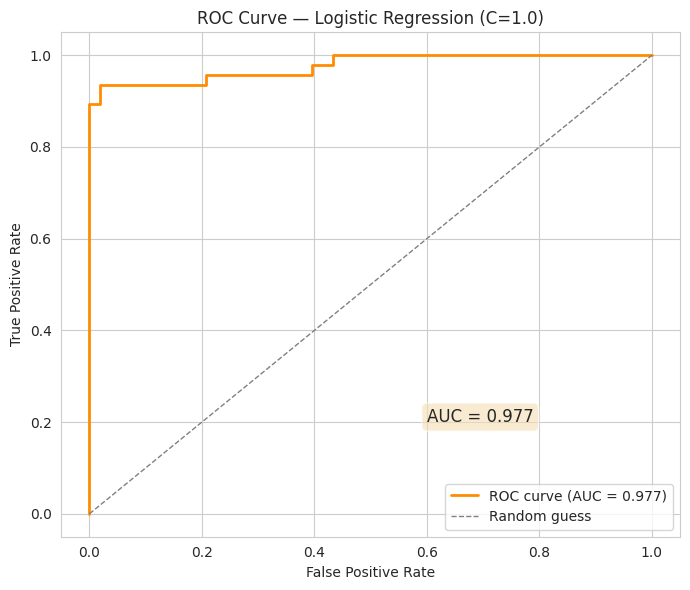

AUC: 0.9771


In [12]:
fpr, tpr, roc_thresholds = roc_curve(y_clf_test, y_proba_clf)
auc_score = roc_auc_score(y_clf_test, y_proba_clf)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (C=1.0)')
plt.annotate(f'AUC = {auc_score:.3f}', xy=(0.6, 0.2), fontsize=12,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")

**Precision and Recall formulas:**

$$Precision = \\frac{TP}{TP + FP}$$
$$Recall = \\frac{TP}{TP + FN}$$

**Which matters more here?** The classification task is identifying "high-cost" policyholders (above
median expenses) — presumably so an insurer can flag them for review, adjust premiums, or plan reserves.
In that context, a **false negative** (missing a genuinely high-cost policyholder) is more costly than a
**false positive** (flagging someone as high-cost who turns out not to be) — an insurer that fails to
anticipate a high-cost case is financially exposed, whereas a false positive just means a bit of extra
scrutiny on a policyholder who didn't need it. So **recall is the more important metric** for this task.

**What the AUC value means:** an AUC of **~0.977** means that if you pick one random high-cost
policyholder and one random low-cost policyholder from the test set, the model assigns a higher predicted
probability to the actual high-cost one about 97.7% of the time. This is very strong separation between
the two classes — `smoker` and `age`/`bmi` together give the model a lot of signal to work with.

## Task 5b — Decision-Threshold Sensitivity

Using the same fitted model's predicted probabilities, we vary the decision threshold from 0.30 to 0.70
in steps of 0.10 and recompute precision, recall, and F1 at each threshold.

In [13]:
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_rows = []

for t in thresholds_to_test:
    preds_at_t = (y_proba_clf >= t).astype(int)
    p = precision_score(y_clf_test, preds_at_t)
    r = recall_score(y_clf_test, preds_at_t)
    f1 = f1_score(y_clf_test, preds_at_t)
    threshold_rows.append({'Threshold': t, 'Precision': p, 'Recall': r, 'F1': f1})

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Threshold,Precision,Recall,F1
0,0.3,0.703125,0.957447,0.810811
1,0.4,0.762712,0.957447,0.849057
2,0.5,0.830189,0.936170,0.880000
3,0.6,0.916667,0.936170,0.926316
4,0.7,0.977273,0.914894,0.945055


In [14]:
best_row = threshold_df.loc[threshold_df['F1'].idxmax()]
print("Threshold that maximises F1-score:")
print(best_row)

Threshold that maximises F1-score:
Threshold    0.700000
Precision    0.977273
Recall       0.914894
F1           0.945055
Name: 4, dtype: float64


**Precision:** $Precision = \\dfrac{TP}{TP + FP}$
**Recall:** $Recall = \\dfrac{TP}{TP + FN}$

**F1-maximising threshold:** **0.70**, with Precision ≈ 0.977, Recall ≈ 0.915, F1 ≈ 0.945.

**Which metric matters more for this task?** As discussed above, **recall** is more business-critical
here — missing a genuinely high-cost policyholder (a false negative) is more expensive for the insurer
than over-flagging a low-cost one. Note that the F1-optimal threshold (0.70) actually **favors precision
over recall** compared to the default 0.50 threshold (recall drops slightly from 0.936 at 0.50 to 0.915 at
0.70, while precision rises from 0.830 to 0.977).

**Would we raise or lower the threshold?** Since recall is what matters most for this use case, we would
**lower** the threshold below the F1-optimal point — e.g. back toward 0.30–0.40, where recall is at its
highest (~0.957). **The cost of doing so** is a drop in precision (down to ~0.70–0.76 at those
thresholds) — the model would flag more false positives (policyholders incorrectly identified as
high-cost), which means more unnecessary manual review, but that trade-off is acceptable given that
missing a real high-cost case is the more expensive mistake.

## Task 6 — Regularization Experiment (C=0.01 vs. C=1.0)

In [15]:
log_reg_strong = LogisticRegression(max_iter=1000, C=0.01, class_weight='balanced', random_state=42)
log_reg_strong.fit(X_train_scaled, y_clf_train)

y_pred_strong = log_reg_strong.predict(X_test_scaled)
y_proba_strong = log_reg_strong.predict_proba(X_test_scaled)[:, 1]

precision_baseline = precision_score(y_clf_test, y_pred_clf)
recall_baseline = recall_score(y_clf_test, y_pred_clf)
auc_baseline = roc_auc_score(y_clf_test, y_proba_clf)

precision_strong = precision_score(y_clf_test, y_pred_strong)
recall_strong = recall_score(y_clf_test, y_pred_strong)
auc_strong = roc_auc_score(y_clf_test, y_proba_strong)

reg_comparison = pd.DataFrame({
    'Model': ['Logistic Regression (C=1.0)', 'Logistic Regression (C=0.01)'],
    'Precision': [precision_baseline, precision_strong],
    'Recall': [recall_baseline, recall_strong],
    'AUC': [auc_baseline, auc_strong]
})
reg_comparison

,Model,Precision,Recall,AUC
0,Logistic Regression (C=1.0),0.830189,0.93617,0.977118
1,Logistic Regression (C=0.01),0.814815,0.93617,0.970695


**What `C` controls:** in scikit-learn's `LogisticRegression`, `C` is the **inverse of the
regularization strength** — it's the weight placed on fitting the training data well versus keeping the
model's coefficients small. A **smaller `C`** (like 0.01) means **stronger L2 regularization**, which
shrinks the coefficients more aggressively toward zero. This tends to produce a simpler, "flatter" decision
boundary that is less sensitive to any single feature or to noise in the training data, at the risk of
underfitting if `C` is pushed too low.

**Did reducing C help or hurt on this dataset?** Reducing `C` from 1.0 to 0.01 **slightly worsened**
performance — AUC dropped from ~0.977 to ~0.971, and precision dropped slightly too, while recall stayed
essentially the same. This suggests the baseline model (C=1.0) wasn't overfitting in a way that heavy
regularization would fix — the relationship between the features (especially `smoker`, `age`, `bmi`) and
the target is strong and fairly clean in this data, so shrinking the coefficients more aggressively just
removes some genuinely useful signal rather than removing noise.

## Task 7 — Bootstrap Confidence Interval for the AUC Difference

We quantify how reliably the C=1.0 model outperforms the C=0.01 model by resampling the test set with
replacement 500 times and computing the AUC difference each time.

In [16]:
np.random.seed(42)
n_boot = 500
y_test_arr = y_clf_test.values
auc_diffs = []

for i in range(n_boot):
    idx = np.random.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    y_sample = y_test_arr[idx]
    if len(np.unique(y_sample)) < 2:
        continue  # AUC undefined if the bootstrap sample has only one class present
    proba1_sample = y_proba_clf[idx]     # C=1.0 model probabilities
    proba2_sample = y_proba_strong[idx]  # C=0.01 model probabilities
    auc1 = roc_auc_score(y_sample, proba1_sample)
    auc2 = roc_auc_score(y_sample, proba2_sample)
    auc_diffs.append(auc1 - auc2)

auc_diffs = np.array(auc_diffs)
mean_diff = auc_diffs.mean()
ci_lower, ci_upper = np.percentile(auc_diffs, [2.5, 97.5])

print(f"Bootstrap samples used: {len(auc_diffs)}")
print(f"Mean AUC difference (C=1.0 minus C=0.01): {mean_diff:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

Bootstrap samples used: 500
Mean AUC difference (C=1.0 minus C=0.01): 0.0062
95% CI: [-0.0020, 0.0189]


**Interpretation:** the mean bootstrap AUC difference is **+0.0062** (C=1.0 model has slightly
higher AUC on average), with a 95% confidence interval of **[-0.0020, 0.0189]**. Because this interval
**includes zero**, the apparent advantage of the C=1.0 model over the C=0.01 model **is not statistically
reliable** at the 95% level — across different resamples of the test set, the difference in AUC sometimes
flips sign. In practice, this means we shouldn't over-index on the small AUC gap between the two
regularization settings; both models perform comparably well, and the choice between them could
reasonably come down to other considerations (e.g. preferring the less-regularized model since it isn't
underperforming, or preferring the more-regularized one for robustness on future, potentially noisier
data).